In [1]:
# Data handling libraries
import pandas as pd
import numpy as np

# Text processing
import re
import nltk

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP utilities
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Machine Learning utilities
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
import zipfile

# ZIP file name
zip_file = "archive (4).zip"

# Extracting folder name
extract_folder = "resume_dataset"

# Extracting files
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

print(os.listdir("resume_dataset"))

['data', 'Resume']


In [4]:
import os

print(os.listdir("resume_dataset/Resume"))

['Resume.csv']


In [5]:
import pandas as pd

# Loading dataset
df = pd.read_csv("resume_dataset/Resume/resume.csv")

# Displaying first 5 rows
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [6]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Dataset information
print("\nDataset Info:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Category distribution
print("\nResume Categories:")
print(df['Category'].value_counts())

Dataset Shape: (2484, 4)

Column Names:
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB
None

Missing Values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Resume Categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCAR

In [7]:
# Function to clean resume text

def clean_resume(text):

    # Removing URLs
    text = re.sub(r'http\S+', ' ', text)

    # Removing RT and cc
    text = re.sub(r'\bRT\b|\bcc\b', ' ', text)

    # Removing hashtags and mentions
    text = re.sub(r'#\S+|@\S+', ' ', text)

    # Removing special characters and punctuation
    text = re.sub(r'[^A-Za-z\s]', ' ', text)

    # Removing extra whitespace
    text = re.sub(r'\s+', ' ', text)

    # Converting to lowercase
    text = text.lower()

    return text.strip()

In [8]:
# Apply cleaning function to Resume_str column

df['Cleaned_Resume'] = df['Resume_str'].apply(clean_resume)

# Display original vs cleaned resume
df[['Resume_str', 'Cleaned_Resume']].head()

,Resume_str,Cleaned_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in r...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [9]:
# Download required NLTK resources

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kanch\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kanch\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
# Load English stopwords
stop_words = set(stopwords.words('english'))

# Function to remove stopwords
def remove_stopwords(text):

    # Tokenize words
    words = word_tokenize(text)

    # Remove stopwords
    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    # Join words back into sentence
    return " ".join(filtered_words)


# Apply stopword removal
df['Processed_Resume'] = df['Cleaned_Resume'].apply(remove_stopwords)

# Display results
df[['Cleaned_Resume', 'Processed_Resume']].head()

,Cleaned_Resume,Processed_Resume
0,hr administrator marketing associate hr admini...,hr administrator marketing associate hr admini...
1,hr specialist us hr operations summary versati...,hr specialist us hr operations summary versati...
2,hr director summary over years experience in r...,hr director summary years experience recruitin...
3,hr specialist summary dedicated driven and dyn...,hr specialist summary dedicated driven dynamic...
4,hr manager skill highlights hr skills hr depar...,hr manager skill highlights hr skills hr depar...


In [11]:
# List of important technical and professional skills

skills = [
    'python',
    'java',
    'c++',
    'sql',
    'machine learning',
    'deep learning',
    'data science',
    'nlp',
    'tensorflow',
    'pandas',
    'numpy',
    'excel',
    'power bi',
    'tableau',
    'communication',
    'leadership',
    'management',
    'recruitment',
    'marketing',
    'sales'
]

print("Total Skills:", len(skills))
print(skills)

Total Skills: 20
['python', 'java', 'c++', 'sql', 'machine learning', 'deep learning', 'data science', 'nlp', 'tensorflow', 'pandas', 'numpy', 'excel', 'power bi', 'tableau', 'communication', 'leadership', 'management', 'recruitment', 'marketing', 'sales']


In [12]:
# Function to extract skills from resume

def extract_skills(resume_text):

    extracted_skills = []

    for skill in skills:

        # Check if skill exists in resume
        if skill.lower() in resume_text.lower():
            extracted_skills.append(skill)

    return extracted_skills


# Apply skill extraction
df['Extracted_Skills'] = df['Processed_Resume'].apply(extract_skills)

# Display results
df[['Processed_Resume', 'Extracted_Skills']].head()

,Processed_Resume,Extracted_Skills
0,hr administrator marketing associate hr admini...,"[leadership, management, marketing, sales]"
1,hr specialist us hr operations summary versati...,"[communication, management, recruitment, marke..."
2,hr director summary years experience recruitin...,"[excel, leadership, management, recruitment, m..."
3,hr specialist summary dedicated driven dynamic...,"[excel, communication, management]"
4,hr manager skill highlights hr skills hr depar...,"[excel, leadership, management, recruitment]"


In [13]:
# Sample Job Description

job_description = """
We are looking for a Data Scientist with strong skills in
Python, Machine Learning, Deep Learning, SQL, NLP,
TensorFlow, Pandas, NumPy, communication, and leadership.
"""

print(job_description)


We are looking for a Data Scientist with strong skills in
Python, Machine Learning, Deep Learning, SQL, NLP,
TensorFlow, Pandas, NumPy, communication, and leadership.



In [14]:
# Combine resumes with job description

resume_texts = df['Processed_Resume'].tolist()

all_documents = resume_texts + [job_description]


# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer()

# Convert text into numerical vectors
tfidf_matrix = tfidf.fit_transform(all_documents)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (2485, 37486)


In [15]:
# Calculate cosine similarity between resumes and job description

cosine_sim = cosine_similarity(
    tfidf_matrix[-1],      # Job Description
    tfidf_matrix[:-1]      # All resumes
)

# Convert similarity scores into list
similarity_scores = cosine_sim.flatten()

# Add scores to dataframe
df['Similarity_Score'] = similarity_scores

# Display top scores
df[['Category', 'Similarity_Score']].head()

,Category,Similarity_Score
0,HR,0.006069
1,HR,0.005176
2,HR,0.001502
3,HR,0.003277
4,HR,0.004063


In [16]:
# Sort resumes based on similarity score

ranked_resumes = df.sort_values(
    by='Similarity_Score',
    ascending=False
)

# Display top 10 candidates
ranked_resumes[
    ['Category', 'Similarity_Score', 'Extracted_Skills']
].head(10)

,Category,Similarity_Score,Extracted_Skills
926,AGRICULTURE,0.128152,"[python, java, sql, tensorflow, pandas, excel,..."
1339,AUTOMOBILE,0.096655,"[python, sql, data science, pandas, numpy, exc..."
1762,ENGINEERING,0.094669,"[python, sql, machine learning, pandas, excel,..."
2153,BANKING,0.080928,"[python, sql, machine learning, management]"
2291,ARTS,0.080257,"[leadership, management]"
1142,CONSULTANT,0.074740,"[java, sql, excel, tableau, communication, man..."
1218,CONSULTANT,0.074049,"[python, java, sql, machine learning, data sci..."
194,DESIGNER,0.069188,"[management, sales]"
374,TEACHER,0.061834,"[excel, communication, leadership, management]"
229,INFORMATION-TECHNOLOGY,0.061197,"[sql, communication, leadership, management, m..."


In [17]:
# Required skills from job description

required_skills = [
    'python',
    'machine learning',
    'deep learning',
    'sql',
    'nlp',
    'tensorflow',
    'pandas',
    'numpy'
]


# Function to identify missing skills

def skill_gap_analysis(candidate_skills):

    missing_skills = []

    for skill in required_skills:

        if skill not in candidate_skills:
            missing_skills.append(skill)

    return missing_skills


# Apply skill gap analysis
df['Missing_Skills'] = df['Extracted_Skills'].apply(skill_gap_analysis)

# Display results
df[['Extracted_Skills', 'Missing_Skills']].head()

,Extracted_Skills,Missing_Skills
0,"[leadership, management, marketing, sales]","[python, machine learning, deep learning, sql,..."
1,"[communication, management, recruitment, marke...","[python, machine learning, deep learning, sql,..."
2,"[excel, leadership, management, recruitment, m...","[python, machine learning, deep learning, sql,..."
3,"[excel, communication, management]","[python, machine learning, deep learning, sql,..."
4,"[excel, leadership, management, recruitment]","[python, machine learning, deep learning, sql,..."


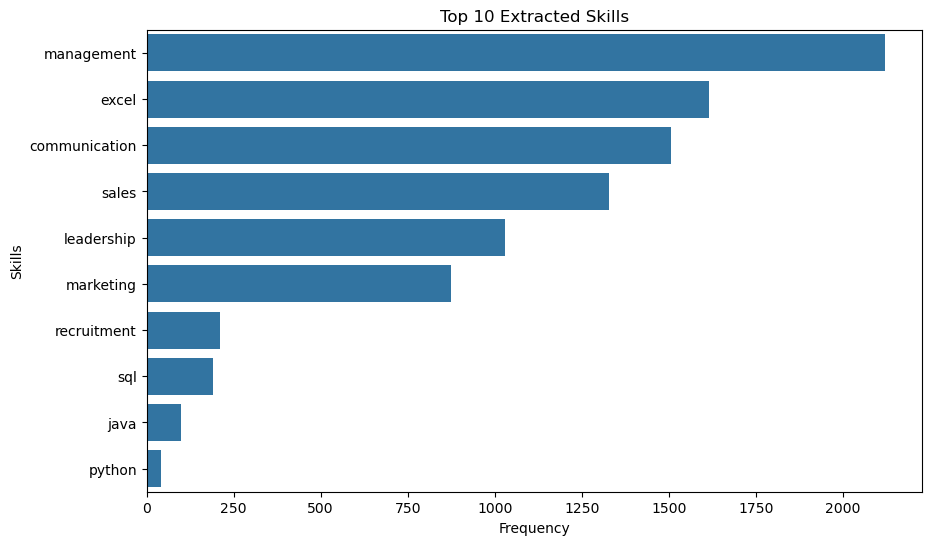

In [18]:
from collections import Counter

# Combine all extracted skills into one list
all_skills = []

for skills_list in df['Extracted_Skills']:
    all_skills.extend(skills_list)

# Count skill frequency
skill_counts = Counter(all_skills)

# Convert to dataframe
skills_df = pd.DataFrame(
    skill_counts.items(),
    columns=['Skill', 'Count']
)

# Sort by frequency
skills_df = skills_df.sort_values(
    by='Count',
    ascending=False
)

# Top 10 skills
top_skills = skills_df.head(10)

# Plot graph
plt.figure(figsize=(10,6))

sns.barplot(
    x='Count',
    y='Skill',
    data=top_skills
)

plt.title("Top 10 Extracted Skills")
plt.xlabel("Frequency")
plt.ylabel("Skills")

plt.show()

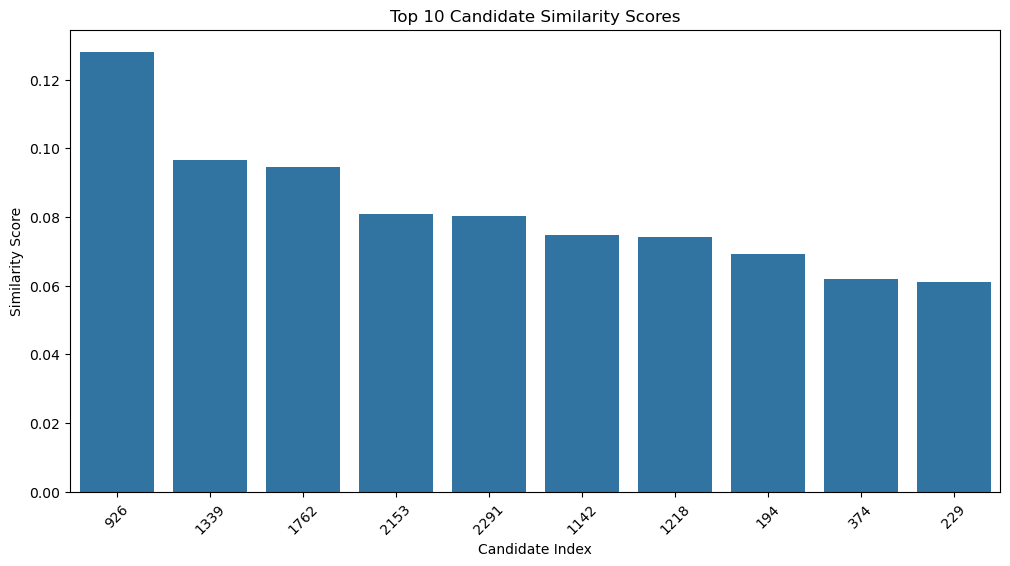

In [19]:
# Top 10 ranked candidates

top_candidates = ranked_resumes.head(10)

# Plot similarity scores

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_candidates.index.astype(str),
    y='Similarity_Score',
    data=top_candidates
)

plt.title("Top 10 Candidate Similarity Scores")
plt.xlabel("Candidate Index")
plt.ylabel("Similarity Score")

plt.xticks(rotation=45)

plt.show()

In [20]:
# Interactive Resume Screening System

def screen_resume(job_description, resume_text):

    # Step 1: Clean Resume
    cleaned_resume = clean_resume(resume_text)

    # Step 2: Remove stopwords
    processed_resume = remove_stopwords(cleaned_resume)

    # Step 3: Extract candidate skills
    candidate_skills = extract_skills(processed_resume)

    # Step 4: Clean Job Description
    cleaned_jd = clean_resume(job_description)

    # Step 5: Remove stopwords from JD
    processed_jd = remove_stopwords(cleaned_jd)

    # Step 6: TF-IDF Vectorization
    documents = [processed_resume, processed_jd]

    vectorizer = TfidfVectorizer()

    tfidf_matrix = vectorizer.fit_transform(documents)

    # Step 7: Similarity Calculation
    similarity = cosine_similarity(
        tfidf_matrix[0:1],
        tfidf_matrix[1:2]
    )[0][0]

    # Step 8: Required Skills from JD
    required = extract_skills(processed_jd)

    # Step 9: Missing Skills
    missing = [
        skill for skill in required
        if skill not in candidate_skills
    ]

    # Final Results
    print("Extracted Skills:")
    print(candidate_skills)

    print("\nRequired Skills:")
    print(required)

    print("\nSimilarity Score:")
    print(round(similarity, 4))

    print("\nMissing Skills:")
    print(missing)

In [21]:
# Interactive ATS Resume Screening

while True:

    print("\n========== Resume Screening System ==========")

    # User inputs
    job_description = input("\nEnter Job Description:\n")

    resume = input("\nEnter Resume Text:\n")

    # Run screening
    screen_resume(job_description, resume)

    # Continue option
    choice = input("\nDo you want to screen another resume? (yes/no): ")

    if choice.lower() != 'yes':
        print("\nExiting Resume Screening System...")
        break


========== Resume Screening System ==========



Enter Job Description:
 Hiring an HR Manager with skills in recruitment, employee management, leadership, communication, and organizational development.

Enter Resume Text:
 Experienced HR Manager skilled in recruitment, employee relations, leadership, communication, performance management, and training.


Extracted Skills:
['communication', 'leadership', 'management', 'recruitment']

Required Skills:
['communication', 'leadership', 'management', 'recruitment']

Similarity Score:
0.4414

Missing Skills:
[]



Do you want to screen another resume? (yes/no):  yes



========== Resume Screening System ==========



Enter Job Description:
 Seeking a Business Analyst with knowledge of SQL, Excel, Power BI, Tableau, communication, management, and reporting skills.

Enter Resume Text:
 Business Analyst experienced in SQL, Excel, Power BI, Tableau, reporting, and dashboard creation. Strong communication and management skills.


Extracted Skills:
['sql', 'excel', 'power bi', 'tableau', 'communication', 'management']

Required Skills:
['sql', 'excel', 'power bi', 'tableau', 'communication', 'management']

Similarity Score:
0.6544

Missing Skills:
[]



Do you want to screen another resume? (yes/no):  no



Exiting Resume Screening System...


**Conclusion**

This project developed an NLP-based Resume Screening and Candidate Ranking System using Python and Machine Learning techniques. The system preprocesses resume text, extracts important skills, compares resumes with job descriptions using TF-IDF and Cosine Similarity, and ranks candidates based on relevance. It also identifies missing skills to help recruiters evaluate applicants more efficiently. The project demonstrates a practical implementation of an Applicant Tracking System (ATS) used in modern recruitment workflows.
